# JensenShannonDivergence: Tutorial

This notebook shows two ways to use the library:

**Mode 1: Use a predefined experiment** 
- 1. Load data from a built-in use case
- 2. Train the estimator
- 3. Estimate Jensen-Shannon divergence

**Mode 2: Use your own data** 
- 1. Provide your reference and synthetic tensors
- 2. Run the Jensen-Shannon estimator directly

Internal details: The train / validation / test split is created automatically when calling `split_estimation_data(train_m)`.

In [1]:
from pathlib import Path
import sys
import json
import random

import numpy as np
import pandas as pd

# Resolve project root whether notebook runs from repo root or from experiments/
cwd = Path.cwd().resolve()
if (cwd / 'src' / 'jensenshannondivergence').exists():
    project_root = cwd
elif (cwd.parent / 'src' / 'jensenshannondivergence').exists():
    project_root = cwd.parent
else:
    project_root = Path('/home/alba/snap/snapd-desktop-integration/jensenshannondivergence')

src_root = project_root / 'src'
experiments_path = project_root / 'experiments'

for p in [src_root, experiments_path]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Imports
from data import load_data
from jensenshannondivergence.estimator.evaluator import DivergenceEvaluator
from jensenshannondivergence.utils import experiments_root
print('project_root =', project_root)
print('experiments_root =', experiments_root())

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
project_root = /home/alba/snap/snapd-desktop-integration/jensenshannondivergence
experiments_root = /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments


## Configuration

Change this section to try other estimators and experiments.

In [2]:
# ============================================
# Choose your mode
# ============================================
# Default is custom-first: set MODE to "custom" to run with your own tensors
MODE = "custom"  # "predefined" or "custom"

# Common settings (both modes)
# NOTE: In custom mode you must pass `discriminator_type` to run().
discriminator_type = 'MLP'     # MLP | RF | XGBoost | LogReg | LogRegPol | TabPFN
seed = 0
epochs = 300                    # Increase for better convergence
n_iter = 20                     # BayesSearchCV iterations (RF/LogReg/XGBoost/LogRegPol)

# ============================================
# MODE 1: PREDEFINED EXPERIMENT
# ============================================
if MODE == "predefined":
    experiment = 'use_case_1'      # Example: use_case_1 
    n = None                         
    m = 200
    l = 200
    data_path = None
    # Example for real data:
    # data_path = str(experiments_root() / 'data' / 'adult' / 'ctgan') + '/'

# ============================================
# MODE 2: YOUR OWN DATA
# ============================================
elif MODE == "custom":
    experiment = None               # Will be set to "custom_data"
    # You must provide your own torch tensors here:
    import torch
    torch.manual_seed(seed)
    
    # Example: generate random data
    n_samples = 400
    n_features = 10
    x_reference = torch.randn(n_samples, n_features)
    x_synthetic = torch.randn(n_samples, n_features)
    
    # Sizes for split
    m = n_samples          # reference sample size
    l = n_samples // 2     # synthetic sample size
    n = None
    data_path = None

random.seed(seed)
np.random.seed(seed)

In [3]:
# ============================================
# Step 1: Get your data
# ============================================
if MODE == "predefined":
    # Load from predefined experiment
    x_r, x_s, dist_r, dist_s = load_data(
        experiment=experiment,
        n=n,
        m=m,
        l=l,
        seed=seed,
        data_path=data_path,
    )
else:
    # Use your own tensors (defined in config cell above)
    x_r = x_reference
    x_s = x_synthetic
    dist_r = None
    dist_q = None

# ============================================
# Step 2: Create estimator and run
# ============================================
from jensenshannondivergence import JSDEstimator

estimator = JSDEstimator()

# In custom mode you must pass the discriminator_type explicitly to run()
run_kwargs = dict(
    n=n,
    seed=seed,
    epochs=epochs,
)
if MODE == "custom":
    run_kwargs.update(dict(x_p=x_r, x_q=x_s, discriminator_type=discriminator_type))
else:
    run_kwargs.update(dict(experiment=experiment, data_path=data_path, use_predefined=True))
 
result = estimator.run(**run_kwargs)

evaluator = result.evaluator

# ============================================
# Step 3: Summarize results
# ============================================
def _to_float(value):
    if value is None:
        return None
    if hasattr(value, 'item'):
        return float(value.item())
    return float(value)

summary = {
    'mode': MODE,
    'experiment': result.experiment,
    'discriminator_type': discriminator_type,
    'seed': seed,
    'n': n,
    'm': m,
    'l': l,
    'mc_gt_js': _to_float(evaluator.mc_gt_js),
    'mc_js': _to_float(evaluator.mc_js),
    'disc_js': _to_float(evaluator.disc_js),
    'training_time_s': _to_float(evaluator.computation_time),
    'output_dir': str(result.results_path),
}

print("\n=== JS Divergence Estimation Results ===")
for k, v in summary.items():
    print(f"{k}: {v}")

summary

Adjusted m,l to fit custom data: m=200, l=100

=== JS Divergence Estimation Results ===
mode: custom
experiment: custom_data
discriminator_type: MLP
seed: 0
n: None
m: 400
l: 200
mc_gt_js: None
mc_js: None
disc_js: 0.0
training_time_s: 3.2043368816375732
output_dir: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_MLP/custom_data


{'mode': 'custom',
 'experiment': 'custom_data',
 'discriminator_type': 'MLP',
 'seed': 0,
 'n': None,
 'm': 400,
 'l': 200,
 'mc_gt_js': None,
 'mc_js': None,
 'disc_js': 0.0,
 'training_time_s': 3.2043368816375732,
 'output_dir': '/home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_MLP/custom_data'}

In [9]:
# ============================================
# Step 4: Save result artifacts
# ============================================
output_dir = result.results_path

summary_json = output_dir / 'summary.json'
summary_csv = output_dir / 'summary.csv'

with open(summary_json, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

pd.DataFrame([summary]).to_csv(summary_csv, index=False)

print(f' Saved summary.json: {summary_json}')
print(f' Saved summary.csv: {summary_csv}')
print(f' Full output directory: {output_dir}')
print(f' Jensen-Shannon Divergence Estimate: {summary["disc_js"]:.6f}')

 Saved summary.json: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_RF/custom_data/summary.json
 Saved summary.csv: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_RF/custom_data/summary.csv
 Full output directory: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_RF/custom_data
 Jensen-Shannon Divergence Estimate: 0.970517


In [10]:
# ---- Custom data example (runnable) ----
import torch
from jensenshannondivergence import JSDEstimator

# Create example data (replace with your tensors)
x_reference = torch.randn(n_samples, n_features)

x_synthetic_1 = torch.randn(n_samples, n_features) + 0.0
x_synthetic_2 = torch.randn(n_samples, n_features) + 1.0
x_synthetic_3 = torch.randn(n_samples, n_features) + 2.5

synthetic_sets = {
    "x_synthetic_1": x_synthetic_1,
    "x_synthetic_2": x_synthetic_2,
    "x_synthetic_3": x_synthetic_3,
}

estimator = JSDEstimator(discriminator_type="RF", n_iter=3)

all_summaries = {}

for name, x_synthetic in synthetic_sets.items():
    result = estimator.run(
        x_p=x_reference,
        x_q=x_synthetic, 
        seed=42,
        epochs=50,
    )

    evaluator = result.evaluator

    disc_js = float(evaluator.disc_js) if evaluator.disc_js is not None else None
    mc_gt_js = float(evaluator.mc_gt_js) if evaluator.mc_gt_js is not None else None

    print(f"\n--- Custom Data Run Summary: {name} ---") 
    print("Discriminator JS estimate:", disc_js) 

    summary = {
        "mode": "custom",
        "dataset": name,
        "m": n_samples,
        "l": n_samples // 2,
        "disc_js": disc_js,
        "mc_gt_js": mc_gt_js,
    }

    all_summaries[name] = summary

    out_path = result.results_path / f"{name}_summary.json"
    with open(out_path, "w", encoding="utf-8") as fh:
        json.dump(summary, fh, indent=2)

    print("Saved summary to", out_path)

print("\n--- All summaries ---")
for name, summary in all_summaries.items():
    print(name, "->", summary["disc_js"])

Adjusted m,l to fit custom data: m=200, l=100
BayesSearchCV: testing 3 parameter combinations (Bayesian optimization)...

--- Custom Data Run Summary: x_synthetic_1 ---
Discriminator JS estimate: 0.0008358359336853027
Saved summary to /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_RF/custom_data/x_synthetic_1_summary.json
Adjusted m,l to fit custom data: m=200, l=100
BayesSearchCV: testing 3 parameter combinations (Bayesian optimization)...

--- Custom Data Run Summary: x_synthetic_2 ---
Discriminator JS estimate: 0.7781998515129089
Saved summary to /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_RF/custom_data/x_synthetic_2_summary.json
Adjusted m,l to fit custom data: m=200, l=100
BayesSearchCV: testing 3 parameter combinations (Bayesian optimization)...

--- Custom Data Run Summary: x_synthetic_3 ---
Discriminator JS estimate: 0.979465126991272
Saved summary to /home/alba/snap/snapd-desktop-integration/jens

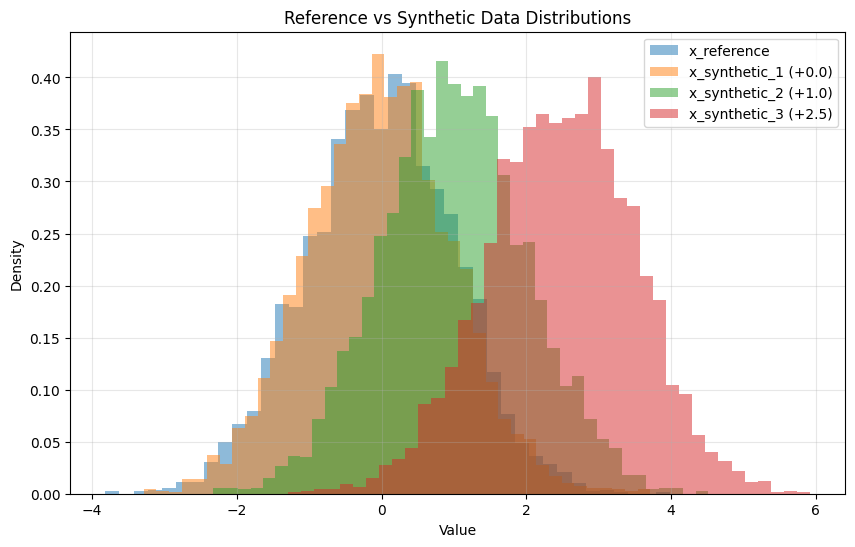

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(x_reference.flatten().detach().cpu().numpy(), bins=40, alpha=0.5, density=True, label="x_reference")
plt.hist(x_synthetic_1.flatten().detach().cpu().numpy(),bins=40,alpha=0.5,density=True,label="x_synthetic_1 (+0.0)")
plt.hist(x_synthetic_2.flatten().detach().cpu().numpy(),bins=40,alpha=0.5,density=True,label="x_synthetic_2 (+1.0)")
plt.hist(x_synthetic_3.flatten().detach().cpu().numpy(),bins=40,alpha=0.5,density=True,label="x_synthetic_3 (+2.5)")
plt.title("Reference vs Synthetic Data Distributions")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Example: Custom Data Usage

The cell below shows how to run the estimator on your own tensors (reference and synthetic). This example generates random tensors for demonstration — replace `x_reference` and `x_synthetic` with your real data tensors.

Notes:
- The estimator defaults to `discriminator_type='MLP'` and `ratio_correction_mode='on'`.
- Provide `m` and `l` when using custom data so splits are computed correctly.